# Data Augmentation per la sicurezza delle centrali elettriche
*Final Project — Generative AI — ProfessionAI*

---

## Contesto del problema

**CyberEye Solutions** è un'azienda che fornisce sistemi di videosorveglianza per infrastrutture critiche, in particolare per le centrali elettriche. Il sistema attuale utilizza modelli di *deep learning* per riconoscere oggetti, anomalie e comportamenti sospetti nelle immagini provenienti dalle telecamere di sicurezza.

Il problema è che i dataset disponibili sono **piccoli** e **poco vari**: questo limita la capacità del modello di funzionare bene in tutte le situazioni reali (luci diverse, angolazioni diverse, condizioni meteo, ecc.).

## Obiettivo

Usare tecniche di **Data Augmentation** basate sull'AI generativa per ampliare il dataset di addestramento e migliorare:
- l'accuratezza del modello,
- la sua capacità di generalizzare a scenari nuovi,
- la velocità nel riconoscere minacce,
- la robustezza complessiva del sistema di sicurezza.

## Approccio proposto

1. **Acquisizione del dataset** — Si usa il dataset *Oxford-IIIT Pet* come banco di prova, perché è pubblico, gratuito e ha la giusta dimensione per fare esperimenti veloci. La pipeline che si costruirà è poi trasferibile a immagini di videosorveglianza reali (vedi la sezione finale del notebook e il `README.md`).
2. **Image Captioning** — Si generano automaticamente descrizioni testuali a partire dalle immagini, usando il modello *BLIP*.
3. **Generazione di varianti testuali** — Si producono caption alternative usando un modello *T5* di paraphrasing.
4. **Generazione di immagini sintetiche** — Si creano nuove immagini a partire dalle descrizioni modificate, usando *Stable Diffusion Turbo*.
5. **Addestramento** — Si addestra un classificatore (*ResNet18*) sia sul dataset originale sia su quello aumentato.
6. **Valutazione** — Si confrontano le performance tramite accuracy, precision, recall, F1 e matrice di confusione.

## Ambiente di esecuzione

Il notebook è pensato per essere eseguito su **Google Colab** con GPU **T4** gratuita (per attivarla: *Runtime → Cambia tipo di runtime → T4 GPU*). Tempo totale stimato: 60-90 minuti.

Le celle sono pensate per essere eseguite **in ordine, dall'alto verso il basso**, una alla volta.

## 1. Setup dell'ambiente

In questa sezione si verifica che la GPU sia attiva, si installano le librerie necessarie e si importano i moduli che verranno usati in tutto il notebook.

In [1]:
# Si importano i moduli standard di Python che servono per controllare il sistema.
import os
import sys
import subprocess

# Si prova a chiamare il comando 'nvidia-smi' per capire se è disponibile una GPU NVIDIA.
# Se siamo su Colab con T4 attiva, questo comando ritorna nome e memoria della GPU.
# Se siamo su un PC normale (es. Mac), il comando non esiste e otteniamo un errore:
# si intercetta quell'errore così il notebook non si blocca.
try:
    gpu_info = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True, check=False
    )
    if gpu_info.stdout.strip():
        print("GPU rilevata:", gpu_info.stdout.strip())
    else:
        print("Nessuna GPU rilevata. Su Colab: Runtime > Cambia tipo di runtime > T4 GPU.")
except FileNotFoundError:
    print("Comando 'nvidia-smi' non trovato: probabilmente non si è su Colab con GPU NVIDIA.")
    print("Il notebook può comunque girare in CPU (molto più lento).")

# Si decide dove salvare gli artefatti (immagini sintetiche, dataset, modelli).
# Su Colab è comodo montare Google Drive per non perdere i file alla fine della sessione.
# Per ora si lascia disattivato (USE_DRIVE = False): tutto verrà salvato nello storage temporaneo.
USE_DRIVE = False

if USE_DRIVE:
    # Su Colab, queste due righe aprono una finestra per autorizzare l'accesso al Drive.
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    PROJECT_ROOT = "/content/drive/MyDrive/cybereye_augmentation"
else:
    # Su Colab senza Drive si salva in /content; in locale si salva nella cartella corrente.
    if "google.colab" in sys.modules:
        PROJECT_ROOT = "/content/cybereye_augmentation"
    else:
        PROJECT_ROOT = "./cybereye_augmentation"

# Si crea la cartella di progetto (exist_ok=True evita errore se già esiste).
os.makedirs(PROJECT_ROOT, exist_ok=True)
print("Cartella di progetto:", PROJECT_ROOT)

GPU rilevata: Tesla T4, 15360 MiB
Cartella di progetto: /content/cybereye_augmentation


### Installazione delle librerie

Su Colab molte librerie sono già preinstallate. Qui si installano solo quelle aggiuntive che servono per la parte generativa (BLIP, T5, Stable Diffusion).

**Attenzione:** Pillow viene reinstallato a una versione precisa, perché su Colab a volte capita che la sua installazione si "rompa" e gli import di torchvision falliscono con l'errore `ImportError: cannot import name '_Ink' from 'PIL._typing'`. Se anche dopo questa cella si vede quell'errore, è sufficiente riavviare il runtime (*Runtime → Riavvia sessione*) e rieseguire le celle dall'inizio.

In [2]:
# Si reinstalla Pillow in una versione stabile. Il flag --no-deps impedisce a pip di
# trascinare aggiornamenti di altri pacchetti (es. torchvision) che funzionano già.
%pip install -q --force-reinstall --no-deps "Pillow==10.4.0"

# Si installano (o aggiornano) le librerie generative.
# Si fissa diffusers a una versione precedente alla 0.32 perché le versioni più nuove
# richiedono modelli di Hugging Face che non sono compatibili con la transformers di Colab.
# Pin di versioni testate insieme. Senza --upgrade pip downgrade transformers
# se Colab ne ha una troppo nuova (es. 4.55+ ha rimosso simboli che diffusers usa).
%pip install -q \
    "transformers>=4.40,<4.50" "diffusers>=0.27,<0.32" "accelerate>=0.28" \
    "sentencepiece" "scikit-learn"

print()
print("Installazione completata.")
print("Se al prossimo import si vede un errore relativo a PIL,")
print("riavviare il runtime (Runtime > Riavvia sessione) e rieseguire le celle.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 50.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.2 MB/s eta 0:00:00

Installazione completata.
Se al prossimo import si vede un errore relativo a PIL,
riavviare il runtime (Runtime > Riavvia sessione) e rieseguire le celle.


In [3]:
# Si importano tutte le librerie che verranno usate nel resto del notebook.
# Si fa qui in un'unica cella per averle tutte sotto controllo.

import random          # per fissare la casualità di Python
import warnings        # per silenziare alcuni avvisi non utili
from pathlib import Path  # gestione comoda dei path dei file

import numpy as np                 # array numerici efficienti
import pandas as pd                # tabelle (DataFrame), tipo Excel ma in Python
import matplotlib.pyplot as plt    # grafici
import seaborn as sns              # grafici più carini (sopra matplotlib)

import torch                       # libreria principale di deep learning
import torch.nn as nn              # moduli per costruire reti neurali
from torch.utils.data import Dataset, DataLoader  # classi per gestire dataset e batch

from torchvision import transforms, models, datasets  # utility per immagini
from PIL import Image              # libreria per aprire/manipolare immagini
from tqdm.auto import tqdm         # barra di avanzamento

# Si nascondono i warning per rendere l'output più leggibile.
warnings.filterwarnings("ignore")

# Si imposta uno stile grafico più gradevole per i grafici di matplotlib/seaborn.
sns.set_theme(context="notebook", style="whitegrid")

# Si fissa il "seme" di tutti i generatori di numeri casuali.
# In questo modo, eseguendo di nuovo il notebook si ottengono gli stessi split,
# le stesse caption, lo stesso ordine dei batch... cioè risultati riproducibili.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Si sceglie automaticamente il dispositivo: GPU se disponibile, altrimenti CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    DTYPE = torch.float16  # fp16 = mezza precisione, dimezza la VRAM usata sulla GPU
else:
    DEVICE = torch.device("cpu")
    DTYPE = torch.float32  # su CPU si usa la precisione piena (standard)

print("Dispositivo in uso:", DEVICE)
print("Tipo numerico per i modelli generativi:", DTYPE)

# Si crea la struttura di cartelle del progetto.
ROOT = Path(PROJECT_ROOT)
DATA_DIR = ROOT / "data"              # dati grezzi
ORIG_DIR = DATA_DIR / "originals"     # immagini originali (non più usata in pratica, ma utile averla)
SYNTH_DIR = DATA_DIR / "synthetic"    # immagini sintetiche generate dal modello
ARTIFACTS = ROOT / "artifacts"        # CSV, log, modelli salvati...

# Si creano tutte le cartelle, exist_ok=True evita errori se già esistono.
for p in [DATA_DIR, ORIG_DIR, SYNTH_DIR, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("Cartelle pronte.")

Dispositivo in uso: cuda
Tipo numerico per i modelli generativi: torch.float16
Cartelle pronte.


## 2. Caricamento del dataset Oxford-IIIT Pet

Il dataset Oxford-IIIT Pet contiene foto di **37 razze** di cani e gatti, circa **200 immagini per razza**, per un totale di poco più di 7400 immagini.

Per rendere l'effetto della data augmentation più visibile, si lavora su un **sottoinsieme volutamente piccolo**: poche razze, poche immagini di training per razza. Così si simula la situazione reale di CyberEye, dove i dati etichettati per le classi rare (intrusione, fumo, guasto) sono pochi.

In [4]:
# Si scelgono 6 razze del dataset: 3 di gatti e 3 di cani.
# I nomi devono essere scritti esattamente come torchvision li carica:
# prima lettera maiuscola, parole separate da spazi (es. "Maine Coon", non "maine_coon").
TARGET_BREEDS = [
    "Abyssinian", "Bengal", "Maine Coon",   # gatti
    "Beagle", "Boxer", "Pug",                # cani
]

# Quanti esempi per razza usare in ogni split.
# Numeri piccoli rendono il task più difficile e mettono in luce il beneficio dell'augmentation.
N_TRAIN_PER_CLASS = 20    # immagini di training per classe (cioè per razza)
N_VAL_PER_CLASS   = 5     # immagini di validazione per classe
N_TEST_PER_CLASS  = 15    # immagini di test per classe

# Quante immagini sintetiche generare per ogni immagine reale di training.
# Con N_TRAIN_PER_CLASS=20 e 6 classi e N_SYNTH_PER_TRAIN=2:
#   - immagini reali di training:    6 * 20 = 120
#   - immagini sintetiche generate:  120 * 2 = 240
#   - dataset aumentato totale:      120 + 240 = 360
N_SYNTH_PER_TRAIN = 2

# Risoluzione finale a cui le immagini verranno ridimensionate per il classificatore.
# 224 è lo standard per le ResNet pre-addestrate su ImageNet.
IMG_SIZE = 224

# Si scarica il dataset (~775 MB). Al primo lancio impiega qualche minuto.
# torchvision lo salva nella cartella indicata e nei lanci successivi lo riusa senza riscaricarlo.
pet_root = DATA_DIR / "oxford-iiit-pet"

trainval = datasets.OxfordIIITPet(
    root=str(pet_root),
    split="trainval",
    target_types="category",
    download=True,
)

test = datasets.OxfordIIITPet(
    root=str(pet_root),
    split="test",
    target_types="category",
    download=True,
)

# La lista 'classes' contiene tutti i nomi delle 37 razze nel formato usato da torchvision.
all_classes = trainval.classes
print("Numero totale di classi nel dataset:", len(all_classes))
print("Prime 5 classi:", all_classes[:5])

100%|██████████| 792M/792M [00:31<00:00, 25.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.2MB/s]


Numero totale di classi nel dataset: 37
Prime 5 classi: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [5]:
# Per comodità, si convertono i dati di torchvision in un DataFrame pandas.
# Un DataFrame è come un foglio Excel: ha righe (le immagini) e colonne (path, label, ecc.).

def to_df(subset, split_name):
    """Converte un oggetto OxfordIIITPet in un DataFrame pandas con path e label."""
    rows = []
    # _images contiene i path delle immagini, _labels gli indici delle classi.
    for img_path, label_idx in zip(subset._images, subset._labels):
        rows.append({
            "path": str(img_path),
            "label_id": int(label_idx),
            "label": all_classes[int(label_idx)],
            "split_src": split_name,
        })
    return pd.DataFrame(rows)

# Si uniscono i due split originali in un unico DataFrame.
# Si rifaranno poi gli split a mano per avere controllo sulla loro composizione.
df_full = pd.concat(
    [to_df(trainval, "trainval"), to_df(test, "test")],
    ignore_index=True,
)

# Si controlla che tutti i nomi in TARGET_BREEDS esistano nel dataset.
# Se non esiste qualche nome, l'assert si blocca e mostra cosa manca e qualche esempio
# di come sono scritti i nomi reali (utile per correggere typo).
missing = set(TARGET_BREEDS) - set(all_classes)
assert not missing, (
    f"Razze sconosciute: {missing}\n"
    f"Esempi disponibili: {sorted(all_classes)[:10]} ...\n"
    f"Nota: torchvision usa .title() e spazi (es. 'Maine Coon', 'Pug')."
)

# Si filtra il DataFrame tenendo solo le righe delle razze scelte.
df = df_full[df_full["label"].isin(TARGET_BREEDS)].reset_index(drop=True)

# Si rimappano i 37 label originali su 0..K-1 per le K razze del subset.
# Esempio: se TARGET_BREEDS ha 6 razze, qui i label diventano 0,1,2,3,4,5.
label2id = {b: i for i, b in enumerate(sorted(TARGET_BREEDS))}
id2label = {i: b for b, i in label2id.items()}
df["label_id"] = df["label"].map(label2id)

NUM_CLASSES = len(label2id)
print("Righe nel subset:", len(df), "| numero classi:", NUM_CLASSES)

# Si mostra quante immagini ci sono per ciascuna classe (prima dello split).
df.groupby("label").size()

Righe nel subset: 1197 | numero classi: 6


,0
label,
Abyssinian,198
Beagle,200
Bengal,200
Boxer,199
Maine Coon,200
Pug,200


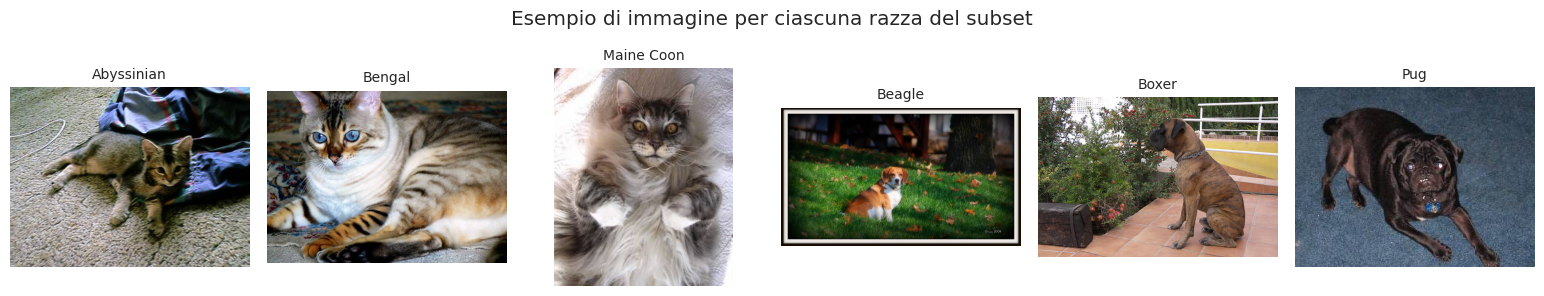

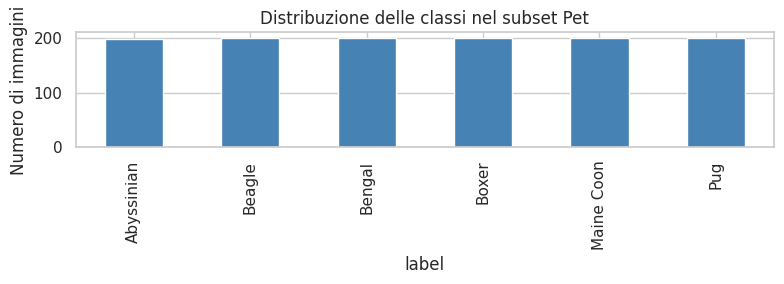

In [6]:
# Si visualizza un campione di immagini per ogni razza, per controllare a colpo d'occhio
# che il dataset sia stato caricato correttamente.

fig, axes = plt.subplots(1, len(TARGET_BREEDS), figsize=(2.6 * len(TARGET_BREEDS), 3))

for ax, breed in zip(axes.flat, TARGET_BREEDS):
    # Si pesca una riga a caso (random_state=SEED rende la scelta riproducibile).
    sample = df[df["label"] == breed].sample(1, random_state=SEED).iloc[0]
    # Si apre l'immagine e la si mostra.
    img = Image.open(sample["path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(breed, fontsize=10)
    ax.axis("off")  # niente assi/numeri intorno all'immagine

plt.suptitle("Esempio di immagine per ciascuna razza del subset")
plt.tight_layout()
plt.show()

# Si mostra anche la distribuzione delle immagini per classe (quante ce ne sono).
counts = df.groupby("label").size()
ax = counts.plot(kind="bar", figsize=(8, 3), color="steelblue")
ax.set_ylabel("Numero di immagini")
ax.set_title("Distribuzione delle classi nel subset Pet")
plt.tight_layout()
plt.show()

In [7]:
# Si dividono i dati in train / validation / test.
# - train:      ciò su cui il modello impara
# - validation: serve a controllare se il modello sta imparando bene durante l'addestramento
# - test:       il giudizio finale, viene usato solo alla fine

def stratified_pick(df_in, n_per_class, rng_seed):
    """Estrae n_per_class righe da ogni classe del DataFrame, in modo riproducibile."""
    chunks = []
    for cls in df_in["label"].unique():
        # Tutte le righe della classe corrente.
        sub = df_in[df_in["label"] == cls]
        # Se ci sono meno righe del richiesto, si prende quello che c'è.
        n_take = min(n_per_class, len(sub))
        chunks.append(sub.sample(n_take, random_state=rng_seed))
    # Si rimettono insieme i pezzi.
    return pd.concat(chunks).reset_index(drop=True)

# Si mescola tutto il DataFrame (frac=1 = tutte le righe, in ordine casuale).
remaining = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Si estrae il train set.
train_df = stratified_pick(remaining, N_TRAIN_PER_CLASS, SEED)
# Si rimuovono le righe già usate dal pool restante.
remaining = remaining[~remaining["path"].isin(train_df["path"])]

# Si estrae il validation set dal pool aggiornato.
val_df = stratified_pick(remaining, N_VAL_PER_CLASS, SEED + 1)
remaining = remaining[~remaining["path"].isin(val_df["path"])]

# Infine si estrae il test set.
test_df = stratified_pick(remaining, N_TEST_PER_CLASS, SEED + 2)

# Si stampa quanti esempi ci sono in ogni split e per ogni classe.
for nome_split, dati_split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{nome_split:>5}: {len(dati_split):>4} img | per classe: {dict(dati_split.groupby('label').size())}")

# Si salvano gli split su disco come file CSV.
# Così sono tracciabili e si possono riaprire più tardi senza rifare il sampling.
train_df.to_csv(ARTIFACTS / "train.csv", index=False)
val_df.to_csv(ARTIFACTS / "val.csv", index=False)
test_df.to_csv(ARTIFACTS / "test.csv", index=False)

train:  120 img | per classe: {'Abyssinian': np.int64(20), 'Beagle': np.int64(20), 'Bengal': np.int64(20), 'Boxer': np.int64(20), 'Maine Coon': np.int64(20), 'Pug': np.int64(20)}
  val:   30 img | per classe: {'Abyssinian': np.int64(5), 'Beagle': np.int64(5), 'Bengal': np.int64(5), 'Boxer': np.int64(5), 'Maine Coon': np.int64(5), 'Pug': np.int64(5)}
 test:   90 img | per classe: {'Abyssinian': np.int64(15), 'Beagle': np.int64(15), 'Bengal': np.int64(15), 'Boxer': np.int64(15), 'Maine Coon': np.int64(15), 'Pug': np.int64(15)}


## 3. Image Captioning con BLIP

**BLIP** (Bootstrapped Language-Image Pretraining) è un modello che, data un'immagine, produce una descrizione testuale (caption) in inglese, tipo:

> *a beagle dog standing on grass*

Si userà la versione "base" da Hugging Face: `Salesforce/blip-image-captioning-base`. La sigla "base" indica che è la versione più piccola/leggera della famiglia, perfetta per la T4.

Le caption verranno generate **solo per le immagini di training**, perché serviranno per produrre le varianti che alimenteranno la generazione di immagini sintetiche. Le immagini di validation e test devono restare "vergini" per poter misurare la generalizzazione vera.

In [8]:
# Si importa BLIP dal modulo transformers.
# BlipProcessor = preprocessing (resize, normalizzazione) e tokenizzazione testo.
# BlipForConditionalGeneration = il modello che, data l'immagine, genera testo.
from transformers import BlipProcessor, BlipForConditionalGeneration

# Identificativo del modello su Hugging Face.
BLIP_ID = "Salesforce/blip-image-captioning-base"

# Si carica il processor (parte CPU, leggera).
blip_processor = BlipProcessor.from_pretrained(BLIP_ID)

# Si carica il modello. Lo si mette su GPU (.to(DEVICE)) e in modalità eval (no training).
# torch_dtype=DTYPE: fp16 su GPU per risparmiare memoria, fp32 su CPU.
blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_ID, torch_dtype=DTYPE)
blip_model = blip_model.to(DEVICE)
blip_model.eval()  # disattiva dropout e batch-norm in modalità training

# Funzione di comodo: data un'immagine PIL, restituisce la caption generata.
def caption_image(pil_img, max_tokens=30):
    # Si trasformano i pixel in un tensore PyTorch sul device giusto.
    inputs = blip_processor(pil_img, return_tensors="pt").to(DEVICE, DTYPE)

    # 'with torch.no_grad()' disattiva il calcolo dei gradienti: serve solo durante il training.
    # Senza, si usa più memoria e si rallenta tutto inutilmente.
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=max_tokens)

    # Si decodifica la sequenza di token in una stringa.
    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption.strip()

print("BLIP caricato e pronto.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP caricato e pronto.


In [9]:
# Si genera una caption per ogni immagine di training.
# La barra di avanzamento (tqdm) mostra a che punto siamo e quanto manca.

captions = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Generazione caption"):
    # Si apre l'immagine e la si converte in RGB (3 canali colore standard).
    img = Image.open(row["path"]).convert("RGB")
    # Si genera la caption.
    cap = caption_image(img)
    captions.append(cap)

# Si aggiunge la colonna 'caption' al DataFrame di training.
# .copy() evita warning di pandas su modifica di una "view".
train_df = train_df.copy()
train_df["caption"] = captions

# Si mostrano le prime righe per verificare che le caption abbiano senso.
train_df.head(8)[["label", "caption"]]

Generazione caption:   0%|          | 0/120 [00:00<?, ?it/s]

,label,caption
0,Boxer,a dog with its tongue out
1,Boxer,a dog laying on a couch
2,Boxer,a dog sleeping on a pillow
3,Boxer,a dog with a tennis ball in its mouth
4,Boxer,a dog laying on a red blanket
5,Boxer,a dog sitting on the floor
6,Boxer,a dog with a chain around its neck
7,Boxer,a dog sitting on the floor


In [10]:
# Si salva il DataFrame con le caption su disco.
train_df.to_csv(ARTIFACTS / "train_with_captions.csv", index=False)

# Si libera la memoria della GPU: si cancella il modello BLIP che non serve più
# nelle fasi successive. Su Colab T4 la VRAM è 16 GB e va gestita con cura.
del blip_model
del blip_processor
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("BLIP rimosso dalla memoria. Caption salvate.")

BLIP rimosso dalla memoria. Caption salvate.


## 4. Generazione di varianti testuali (paraphrasing)

Per ogni caption generata da BLIP si producono **N varianti** (alternative dette in modo diverso ma con lo stesso significato). Ogni variante darà poi origine a un'immagine sintetica differente, aumentando la diversità visiva del dataset.

Si usa il modello **T5** `humarin/chatgpt_paraphraser_on_T5_base`, già fine-tunato per fare paraphrasing.

Esempio:
- caption originale: *"a cat sitting on a bed"*
- variante 1: *"a feline resting on the mattress"*
- variante 2: *"a kitty laying on a blanket"*

Il nome della razza verrà aggiunto in seguito al prompt di generazione, in modo che l'immagine sintetica rappresenti comunque l'animale giusto anche se la caption è generica.

In [11]:
# Si importano le classi per caricare il modello T5 da Hugging Face.
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Identificativo del paraphraser.
PARA_ID = "humarin/chatgpt_paraphraser_on_T5_base"

# Si carica tokenizer e modello.
para_tokenizer = AutoTokenizer.from_pretrained(PARA_ID)
para_model = AutoModelForSeq2SeqLM.from_pretrained(PARA_ID).to(DEVICE)
para_model.eval()

# Funzione di paraphrasing: dato un testo, ritorna n varianti diverse.
def paraphrase(text, n=N_SYNTH_PER_TRAIN):
    # Si trasforma il testo in token, aggiungendo il prefisso "paraphrase: " (richiesto da questo modello).
    inputs = para_tokenizer(
        f"paraphrase: {text}",
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(DEVICE)

    # Si genera N varianti diverse tra loro usando il sampling stocastico.
    # do_sample=True: a ogni passo si sceglie il token in modo casuale (pesato dalle probabilità).
    # top_p=0.95: si considera solo il 95% di probabilità cumulata (nucleus sampling).
    # temperature=1.2: alza la "creatività" del modello (più varianti diverse).
    # In passato si usava group beam search, ma le versioni recenti di transformers
    # lo hanno spostato in un repo esterno: il sampling è più portabile e non richiede
    # codice remoto.
    with torch.no_grad():
        outputs = para_model.generate(
            **inputs,
            do_sample=True,
            top_p=0.95,
            temperature=1.2,
            num_return_sequences=n,
            max_length=64,
            no_repeat_ngram_size=2,
        )

    # Si decodificano tutte le sequenze in stringhe.
    varianti = []
    for o in outputs:
        varianti.append(para_tokenizer.decode(o, skip_special_tokens=True))
    return varianti

print("Paraphraser T5 caricato e pronto.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Paraphraser T5 caricato e pronto.


In [12]:
# Si generano N_SYNTH_PER_TRAIN varianti per ciascuna caption del training set.
# Il risultato è una "tabella lunga": una riga per ogni coppia (immagine, variante).

variant_rows = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Paraphrasing"):
    varianti = paraphrase(row["caption"], n=N_SYNTH_PER_TRAIN)
    for i, v in enumerate(varianti):
        variant_rows.append({
            "src_path": row["path"],          # immagine reale di origine
            "label": row["label"],            # razza (utile per costruire il prompt finale)
            "label_id": row["label_id"],
            "orig_caption": row["caption"],   # caption originale (per confronto)
            "variant_idx": i,                 # indice 0..N-1
            "variant_caption": v,             # la variante effettiva
        })

variants_df = pd.DataFrame(variant_rows)
print("Varianti generate:", len(variants_df),
      f"({N_SYNTH_PER_TRAIN} per ciascuna delle {len(train_df)} immagini di training)")

# Si mostrano le prime righe per controllare che le varianti siano davvero diverse dall'originale.
variants_df.head(6)[["label", "orig_caption", "variant_caption"]]

Paraphrasing:   0%|          | 0/120 [00:00<?, ?it/s]

Varianti generate: 240 (2 per ciascuna delle 120 immagini di training)


,label,orig_caption,variant_caption
0,Boxer,a dog with its tongue out,A dog with an open tongue.
1,Boxer,a dog with its tongue out,Dogs with their tongue out of the air.
2,Boxer,a dog laying on a couch,A dog in a downed couch .
3,Boxer,a dog laying on a couch,"Placing a dog on ,,a couch?"
4,Boxer,a dog sleeping on a pillow,The phenomenon of a dog sleeping on clinching .
5,Boxer,a dog sleeping on a pillow,The act of putting a dog on if it sleeps on it...


In [13]:
# Si salva e si libera memoria.
variants_df.to_csv(ARTIFACTS / "caption_variants.csv", index=False)

del para_model
del para_tokenizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Paraphraser rimosso dalla memoria.")

Paraphraser rimosso dalla memoria.


## 5. Generazione di immagini sintetiche con SD-turbo

**Stable Diffusion Turbo** è una versione "distillata" di Stable Diffusion che produce immagini accettabili in **1-4 step** invece dei classici 25-50. Su una T4 servono circa **3 secondi per immagine** a 512x512 pixel.

Per ogni variante di caption si compone un *prompt* del tipo:

`"a photo of a {breed}, {variant_caption}"`

Il nome della razza funge da **vincolo di classe**: anche se la caption è generica, il modello viene "spinto" a generare un esemplare della razza giusta. La variante aggiunge invece diversità (posa, sfondo, illuminazione).

In [14]:
# Si importa la classe specifica della pipeline di Stable Diffusion.
# Nota: in passato si usava AutoPipelineForText2Image, ma su Colab importa moduli
# (es. aura_flow) che richiedono simboli rimossi nelle versioni più recenti di
# transformers. Usare StableDiffusionPipeline direttamente è più portabile e
# fa lo stesso lavoro per SD-turbo (che è basato sull'architettura SD 1.x).
from diffusers import StableDiffusionPipeline

SD_ID = "stabilityai/sd-turbo"

# variant="fp16" carica direttamente i pesi in mezza precisione (meno VRAM).
# safety_checker=None disattiva il filtro NSFW (non serve per il dataset Pet
# e riduce la VRAM). requires_safety_checker=False evita warning a runtime.
sd = StableDiffusionPipeline.from_pretrained(
    SD_ID,
    torch_dtype=DTYPE,
    variant="fp16",
    safety_checker=None,
    requires_safety_checker=False,
)
sd = sd.to(DEVICE)

# Si disattiva la barra di progresso interna (si usa già tqdm fuori).
sd.set_progress_bar_config(disable=True)

# Si attiva l'attention slicing: riduce i picchi di VRAM dividendo l'attention in chunk.
# Se la versione di diffusers non lo supporta, si ignora l'errore.
try:
    sd.enable_attention_slicing()
except Exception as e:
    print("attention slicing non attivato:", e)

print("Stable Diffusion Turbo caricato e pronto.")

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.73G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Stable Diffusion Turbo caricato e pronto.


In [15]:
# Si generano le immagini sintetiche, una per ciascuna variante di caption.
# Ogni immagine viene salvata su disco e tracciata in un DataFrame.

# Iperparametri specifici di SD-turbo (NON sono quelli di SD 1.5 / 2 / XL):
GEN_STEPS    = 2     # SD-turbo lavora bene con 1-4 step (non 25-50 come SD normale)
GEN_GUIDANCE = 0.0   # SD-turbo richiede guidance_scale = 0
GEN_SIZE     = 512   # risoluzione di generazione

# Si assicura che la cartella di destinazione esista.
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

synth_records = []

for _, row in tqdm(variants_df.iterrows(), total=len(variants_df), desc="Generazione immagini"):
    # Si compone il prompt mettendo davanti il nome della razza per fissare la classe.
    breed_pretty = row["label"].replace("_", " ")
    prompt = f"a photo of a {breed_pretty}, {row['variant_caption']}"

    # Si genera l'immagine. L'output è un oggetto con una lista 'images'.
    out = sd(
        prompt=prompt,
        num_inference_steps=GEN_STEPS,
        guidance_scale=GEN_GUIDANCE,
        height=GEN_SIZE,
        width=GEN_SIZE,
    )
    img = out.images[0]

    # Si costruisce un nome file leggibile e univoco.
    # row["label"] può contenere spazi ("Maine Coon"): si sostituiscono con underscore.
    safe_label = row["label"].replace(" ", "_")
    src_stem = Path(row["src_path"]).stem
    out_path = SYNTH_DIR / f"{safe_label}_{src_stem}_{row['variant_idx']}.png"
    img.save(out_path)

    synth_records.append({
        "path": str(out_path),
        "label": row["label"],
        "label_id": row["label_id"],
        "prompt": prompt,
        "src_path": row["src_path"],
    })

# Si crea l'indice delle immagini sintetiche.
synth_df = pd.DataFrame(synth_records)
synth_df.to_csv(ARTIFACTS / "synth_index.csv", index=False)
print("Immagini sintetiche salvate:", len(synth_df))

Generazione immagini:   0%|          | 0/240 [00:00<?, ?it/s]

Immagini sintetiche salvate: 240


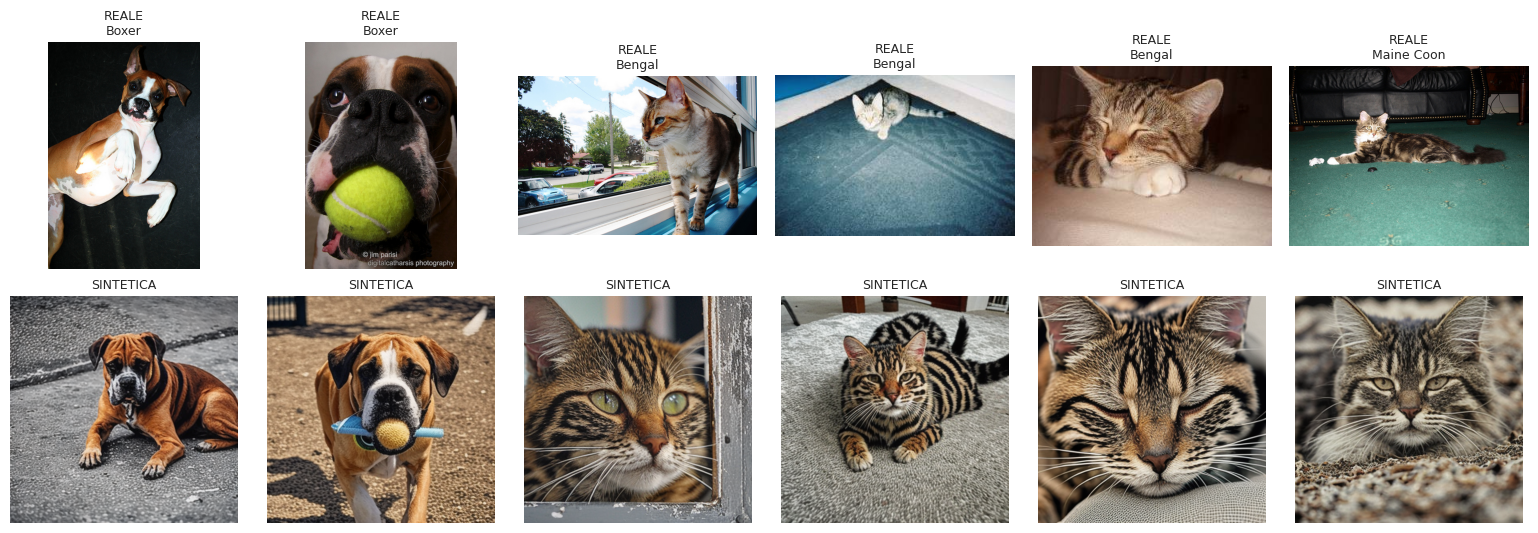

Stable Diffusion rimosso dalla memoria.


In [16]:
# Confronto visivo reale vs sintetico: per qualche esempio si mettono affiancate
# l'immagine reale (sopra) e una sua versione sintetica (sotto).
# Serve a verificare a occhio che il modello stia preservando la classe (es. razza giusta).

sample = synth_df.sample(min(6, len(synth_df)), random_state=SEED).reset_index(drop=True)
n_cols = len(sample)

fig, axes = plt.subplots(2, n_cols, figsize=(2.6 * n_cols, 5.5))

for col, row in sample.iterrows():
    real_img = Image.open(row["src_path"]).convert("RGB")
    fake_img = Image.open(row["path"]).convert("RGB")

    axes[0, col].imshow(real_img)
    axes[0, col].set_title(f"REALE\n{row['label']}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(fake_img)
    axes[1, col].set_title("SINTETICA", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

# Si libera la VRAM occupata da Stable Diffusion: ora servirà per il classificatore.
del sd
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Stable Diffusion rimosso dalla memoria.")

## 6. Costruzione dei dataset PyTorch

A questo punto si hanno:
- `train_df` → immagini reali di training (poche)
- `synth_df` → immagini sintetiche generate (di più)
- `val_df`, `test_df` → solo immagini reali, intoccate

Si preparano **due configurazioni** di addestramento:
- **Baseline:** solo immagini reali (`train_df`).
- **Augmented:** immagini reali + sintetiche (`train_df` ∪ `synth_df`).

Validation e test restano **identici** tra le due configurazioni e contengono **solo immagini reali**. È l'unico modo per dire onestamente che il modello aumentato generalizza meglio: il test set non è "contaminato" dalle immagini sintetiche.

In [17]:
# Valori standard di normalizzazione di ImageNet.
# Le ResNet pre-addestrate si aspettano input normalizzati con questi valori.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Trasformazioni applicate alle immagini in fase di TRAINING.
# Si aggiungono piccole modifiche casuali (crop, flip, jitter) come augmentation "classica":
# è ortogonale a quella generativa e di solito aiuta.
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # un po' più grande del finale...
    transforms.RandomCrop(IMG_SIZE),                    # ...poi ritaglio casuale a IMG_SIZE
    transforms.RandomHorizontalFlip(),                  # specchio orizzontale casuale
    transforms.ColorJitter(0.1, 0.1, 0.1),              # piccoli scostamenti di colore
    transforms.ToTensor(),                              # da PIL a tensore PyTorch
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # normalizzazione canale per canale
])

# Trasformazioni applicate alle immagini in fase di VALUTAZIONE.
# Niente casualità qui: si vuole un risultato deterministico.
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Classe custom di Dataset PyTorch.
# Riceve un DataFrame con colonne 'path' e 'label_id' e fornisce coppie (immagine, etichetta).
class PetDF(Dataset):
    def __init__(self, df_in, tfm):
        # Si fa una copia con indice resettato per evitare problemi di indicizzazione.
        self.df = df_in.reset_index(drop=True)
        self.tfm = tfm  # le trasformazioni da applicare a ogni immagine

    def __len__(self):
        # Lunghezza del dataset (numero di righe).
        return len(self.df)

    def __getitem__(self, i):
        # Restituisce la i-esima coppia (tensore_immagine, label_id).
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        img_tensor = self.tfm(img)
        return img_tensor, int(row["label_id"])

In [18]:
# Si creano i dataset e i loader (batch sampler) per entrambe le configurazioni.

# Dimensione del batch: quanti esempi si processano insieme a ogni step di training.
# 32 è un valore standard per ResNet su immagini 224x224 su una T4.
BATCH = 32

# NUM_WORKERS = 0 significa che il caricamento dei dati avviene nel processo principale.
# Su dataset piccoli come il nostro, di più non aiuta e può creare problemi di pickling
# su alcune piattaforme (es. Mac). 0 funziona sicuramente ovunque.
NUM_WORKERS = 0

# Dataset baseline: solo immagini reali.
baseline_train_ds = PetDF(train_df[["path", "label_id"]], train_tf)

# Dataset augmented: immagini reali concatenate alle sintetiche.
augmented_df = pd.concat(
    [
        train_df[["path", "label_id"]],
        synth_df[["path", "label_id"]],
    ],
    ignore_index=True,
)
augmented_train_ds = PetDF(augmented_df, train_tf)

# Validation e test usano sempre solo immagini reali.
val_ds  = PetDF(val_df[["path", "label_id"]], eval_tf)
test_ds = PetDF(test_df[["path", "label_id"]], eval_tf)

# Funzione di comodo per costruire DataLoader con parametri coerenti.
def make_loader(ds, shuffle):
    return DataLoader(
        ds,
        batch_size=BATCH,
        shuffle=shuffle,       # mescola gli esempi solo in training
        num_workers=NUM_WORKERS,
        pin_memory=True,       # accelera il transfer CPU->GPU se c'è una GPU
    )

baseline_loader  = make_loader(baseline_train_ds, shuffle=True)
augmented_loader = make_loader(augmented_train_ds, shuffle=True)
val_loader       = make_loader(val_ds, shuffle=False)
test_loader      = make_loader(test_ds, shuffle=False)

print("Train baseline:", len(baseline_train_ds),
      "| Train augmented:", len(augmented_train_ds),
      "| Val:", len(val_ds),
      "| Test:", len(test_ds))

Train baseline: 120 | Train augmented: 360 | Val: 30 | Test: 90


## 7. Addestramento del classificatore

Si usa una **ResNet18** già pre-addestrata su ImageNet. Si applica una tecnica chiamata **transfer learning**:
- Si "congela" la parte convoluzionale della rete (i pesi non vengono aggiornati durante il training).
- Si sostituisce solo l'ultimo strato (la "testa") con un nuovo strato adatto al numero di classi del subset.
- Si addestra **solo** la testa.

In questo modo:
- L'addestramento è velocissimo (pochi parametri da aggiornare).
- Si riusa la conoscenza visiva generale di ImageNet.
- Si riduce drasticamente il rischio di overfitting su un dataset piccolo.

Per un confronto **equo**, baseline e augmented usano gli **stessi iperparametri** (epoche, learning rate, ottimizzatore, seed): l'unica differenza è il dataset di training.

In [19]:
# Funzione che costruisce il modello.
def build_model(num_classes):
    # Si carica una ResNet18 con i pesi pre-addestrati su ImageNet.
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Si congelano tutti i parametri (requires_grad=False = non aggiornare durante il training).
    for p in m.parameters():
        p.requires_grad = False

    # Si sostituisce l'ultimo strato (fully connected) con uno nuovo, della giusta dimensione.
    # Solo questo nuovo strato verrà addestrato (i suoi pesi hanno requires_grad=True di default).
    num_features_in = m.fc.in_features
    m.fc = nn.Linear(num_features_in, num_classes)

    return m.to(DEVICE)

# Iperparametri di training.
EPOCHS = 12          # numero di passaggi completi sul dataset
LR = 1e-3            # learning rate

# Funzione di valutazione: gira sul loader e calcola accuracy e loss medi.
def evaluate(model, loader):
    model.eval()  # modalità valutazione (no dropout, no batchnorm update)
    correct = 0
    total = 0
    loss_sum = 0.0
    crit = nn.CrossEntropyLoss(reduction="sum")  # somma invece di media, così possiamo dividere noi

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)               # uscita "grezza" del modello
            loss_sum += crit(logits, y).item()
            preds = logits.argmax(dim=1)    # la classe predetta è quella col logit più alto
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    avg_loss = loss_sum / total
    return acc, avg_loss

# Ciclo di training.
def train(model, train_loader, tag):
    # AdamW = variante moderna di Adam, ottimizzatore standard per fine-tuning.
    # Si aggiornano solo i parametri della testa (model.fc), non quelli del backbone.
    opt = torch.optim.AdamW(model.fc.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()  # loss standard per classificazione multi-classe

    # Si registra la storia delle metriche epoca per epoca per fare i grafici dopo.
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, EPOCHS + 1):
        model.train()  # modalità training (attiva dropout, batchnorm update)
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            # 1) Si azzerano i gradienti dell'epoca precedente.
            opt.zero_grad()
            # 2) Forward pass: si calcola l'uscita del modello.
            logits = model(x)
            # 3) Si calcola la loss (quanto il modello sta sbagliando).
            loss = crit(logits, y)
            # 4) Backward pass: si calcolano i gradienti.
            loss.backward()
            # 5) Si aggiornano i pesi della testa.
            opt.step()

            # Si accumulano statistiche per l'epoca.
            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total += x.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{tag}] epoca {epoch:02d} | "
              f"train_loss {train_loss:.3f} acc {train_acc:.3f} | "
              f"val_loss {val_loss:.3f} acc {val_acc:.3f}")

    return history

In [20]:
# Training della BASELINE: solo immagini reali.
# Si rimette il seed prima della costruzione del modello per essere sicuri che
# l'inizializzazione della testa sia identica nei due esperimenti.
torch.manual_seed(SEED)

baseline_model = build_model(NUM_CLASSES)
hist_baseline = train(baseline_model, baseline_loader, tag="baseline")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


[baseline] epoca 01 | train_loss 1.858 acc 0.192 | val_loss 1.615 acc 0.433
[baseline] epoca 02 | train_loss 1.542 acc 0.367 | val_loss 1.423 acc 0.467
[baseline] epoca 03 | train_loss 1.306 acc 0.583 | val_loss 1.217 acc 0.700
[baseline] epoca 04 | train_loss 1.084 acc 0.750 | val_loss 1.056 acc 0.733
[baseline] epoca 05 | train_loss 0.933 acc 0.833 | val_loss 0.937 acc 0.767
[baseline] epoca 06 | train_loss 0.824 acc 0.858 | val_loss 0.837 acc 0.867
[baseline] epoca 07 | train_loss 0.691 acc 0.875 | val_loss 0.779 acc 0.800
[baseline] epoca 08 | train_loss 0.626 acc 0.900 | val_loss 0.715 acc 0.800
[baseline] epoca 09 | train_loss 0.521 acc 0.958 | val_loss 0.645 acc 0.867
[baseline] epoca 10 | train_loss 0.527 acc 0.942 | val_loss 0.600 acc 0.867
[baseline] epoca 11 | train_loss 0.430 acc 0.942 | val_loss 0.554 acc 0.900
[baseline] epoca 12 | train_loss 0.416 acc 0.942 | val_loss 0.519 acc 0.900


In [21]:
# Training della configurazione AUGMENTED: immagini reali + sintetiche.
torch.manual_seed(SEED)

augmented_model = build_model(NUM_CLASSES)
hist_augmented = train(augmented_model, augmented_loader, tag="augmented")

[augmented] epoca 01 | train_loss 1.596 acc 0.375 | val_loss 1.242 acc 0.600
[augmented] epoca 02 | train_loss 0.930 acc 0.772 | val_loss 0.919 acc 0.700
[augmented] epoca 03 | train_loss 0.639 acc 0.853 | val_loss 0.715 acc 0.767
[augmented] epoca 04 | train_loss 0.499 acc 0.869 | val_loss 0.586 acc 0.833
[augmented] epoca 05 | train_loss 0.401 acc 0.917 | val_loss 0.495 acc 0.900
[augmented] epoca 06 | train_loss 0.342 acc 0.931 | val_loss 0.482 acc 0.833
[augmented] epoca 07 | train_loss 0.314 acc 0.939 | val_loss 0.399 acc 0.900
[augmented] epoca 08 | train_loss 0.289 acc 0.933 | val_loss 0.390 acc 0.900
[augmented] epoca 09 | train_loss 0.240 acc 0.964 | val_loss 0.370 acc 0.900
[augmented] epoca 10 | train_loss 0.231 acc 0.956 | val_loss 0.368 acc 0.900
[augmented] epoca 11 | train_loss 0.197 acc 0.964 | val_loss 0.318 acc 0.933
[augmented] epoca 12 | train_loss 0.219 acc 0.956 | val_loss 0.317 acc 0.900


## 8. Valutazione sul test set

Adesso si misura davvero quanto i due modelli generalizzano. Il test set contiene **solo immagini reali** ed è **identico** per entrambi i modelli.

Si calcolano:
- **Accuracy:** frazione di predizioni corrette.
- **Precision (macro):** media della precision per classe; misura quanto le predizioni positive sono affidabili.
- **Recall (macro):** media del recall per classe; misura quanto il modello "trova" gli esempi positivi.
- **F1 (macro):** media armonica di precision e recall.
- **Matrice di confusione:** mostra dove il modello sbaglia (quali classi confonde tra loro).

In [22]:
# Si importano le metriche da scikit-learn.
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Funzione che restituisce due array NumPy: etichette vere e predette per un loader.
def predict_all(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(y.numpy().tolist())

    return np.array(y_true), np.array(y_pred)

# Funzione che riassume le metriche principali in un dizionario.
def summarize(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0,
    )
    return {
        "model": tag,
        "accuracy": acc,
        "precision_macro": p,
        "recall_macro": r,
        "f1_macro": f,
    }

# Si fanno le predizioni dei due modelli sullo stesso test set.
y_true_b, y_pred_b = predict_all(baseline_model, test_loader)
y_true_a, y_pred_a = predict_all(augmented_model, test_loader)

# Si costruisce una tabellina di confronto.
results = pd.DataFrame([
    summarize(y_true_b, y_pred_b, "baseline (solo reali)"),
    summarize(y_true_a, y_pred_a, "augmented (reali + sintetiche)"),
])

results.to_csv(ARTIFACTS / "results.csv", index=False)
results

,model,accuracy,precision_macro,recall_macro,f1_macro
0,baseline (solo reali),0.922222,0.922817,0.922222,0.922185
1,augmented (reali + sintetiche),0.888889,0.888591,0.888889,0.888073


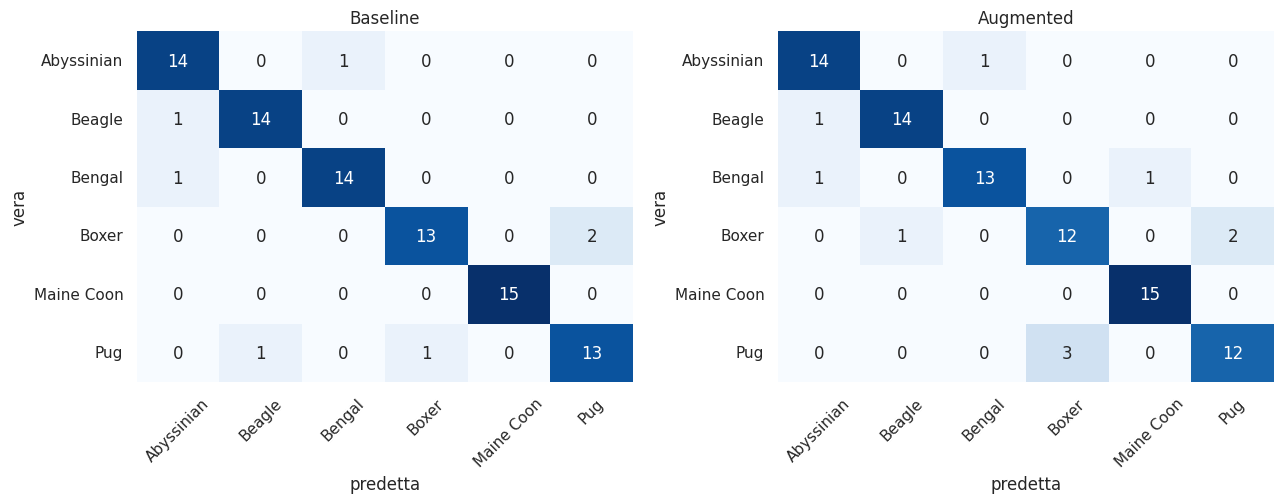

In [23]:
# Matrici di confusione affiancate.
# Sulla diagonale ci sono le predizioni corrette; fuori dalla diagonale, gli errori
# (riga = classe vera, colonna = classe predetta).

# Si ordinano le etichette in modo coerente con gli ID rimappati prima.
labels_sorted = [id2label[i] for i in range(NUM_CLASSES)]

cm_b = confusion_matrix(y_true_b, y_pred_b, labels=list(range(NUM_CLASSES)))
cm_a = confusion_matrix(y_true_a, y_pred_a, labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, cm, title in [(axes[0], cm_b, "Baseline"), (axes[1], cm_a, "Augmented")]:
    sns.heatmap(
        cm,
        annot=True,           # mostra i numeri dentro le celle
        fmt="d",              # come interi
        cmap="Blues",
        cbar=False,
        xticklabels=labels_sorted,
        yticklabels=labels_sorted,
        ax=ax,
    )
    ax.set_xlabel("predetta")
    ax.set_ylabel("vera")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Report dettagliato per classe: precision, recall, f1 e numero di esempi (support).
# Utile per vedere su quali classi specifiche l'augmentation aiuta o peggiora.

print("BASELINE (solo immagini reali)")
print("-" * 60)
print(classification_report(
    y_true_b, y_pred_b,
    target_names=labels_sorted,
    zero_division=0,
))

print()
print("AUGMENTED (immagini reali + sintetiche)")
print("-" * 60)
print(classification_report(
    y_true_a, y_pred_a,
    target_names=labels_sorted,
    zero_division=0,
))

BASELINE (solo immagini reali)
------------------------------------------------------------
              precision    recall  f1-score   support

  Abyssinian       0.88      0.93      0.90        15
      Beagle       0.93      0.93      0.93        15
      Bengal       0.93      0.93      0.93        15
       Boxer       0.93      0.87      0.90        15
  Maine Coon       1.00      1.00      1.00        15
         Pug       0.87      0.87      0.87        15

    accuracy                           0.92        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.92      0.92      0.92        90


AUGMENTED (immagini reali + sintetiche)
------------------------------------------------------------
              precision    recall  f1-score   support

  Abyssinian       0.88      0.93      0.90        15
      Beagle       0.93      0.93      0.93        15
      Bengal       0.93      0.87      0.90        15
       Boxer       0.80      0.80      0.80   

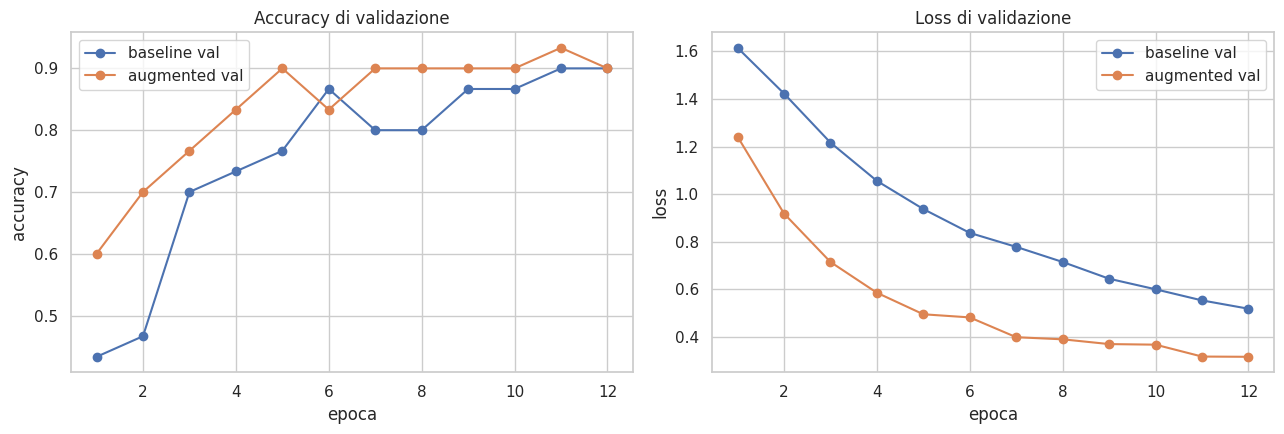

In [25]:
# Curve di apprendimento epoca per epoca.
# Se l'augmentation funziona, ci si aspetta che la curva 'augmented val' stia sopra a quella baseline.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs_axis = np.arange(1, EPOCHS + 1)

# Sinistra: accuracy di validazione.
axes[0].plot(epochs_axis, hist_baseline["val_acc"],  label="baseline val", marker="o")
axes[0].plot(epochs_axis, hist_augmented["val_acc"], label="augmented val", marker="o")
axes[0].set_title("Accuracy di validazione")
axes[0].set_xlabel("epoca")
axes[0].set_ylabel("accuracy")
axes[0].legend()
axes[0].grid(True)

# Destra: loss di validazione.
axes[1].plot(epochs_axis, hist_baseline["val_loss"],  label="baseline val", marker="o")
axes[1].plot(epochs_axis, hist_augmented["val_loss"], label="augmented val", marker="o")
axes[1].set_title("Loss di validazione")
axes[1].set_xlabel("epoca")
axes[1].set_ylabel("loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

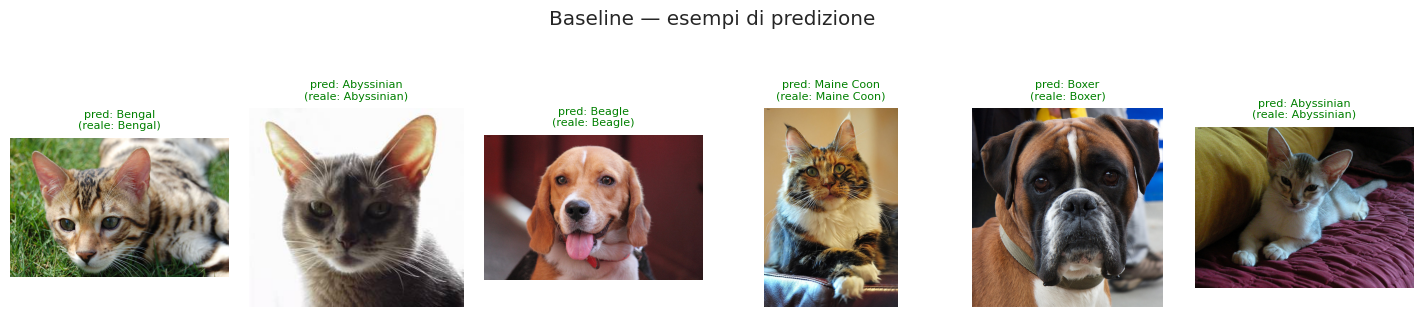

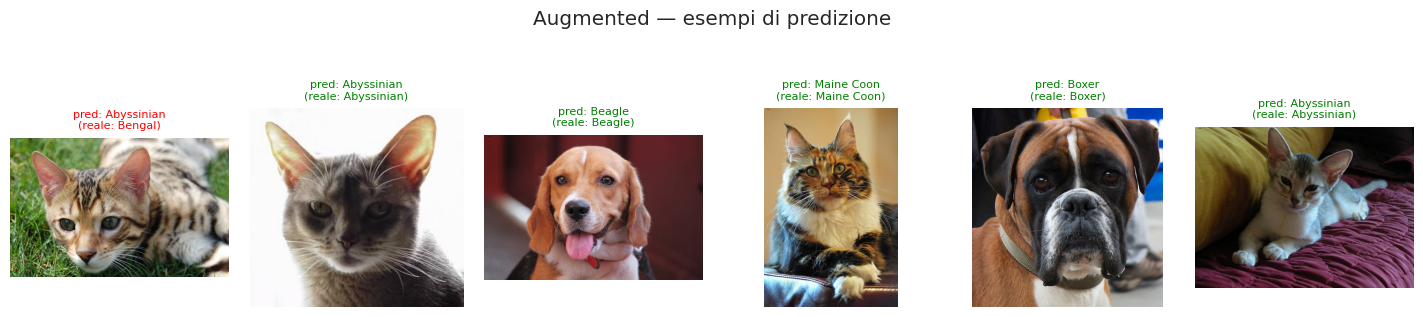

In [26]:
# Visualizzazione qualitativa: alcune predizioni del modello sul test set.
# Titolo verde se la predizione è corretta, rosso se è sbagliata.

def show_predictions(model, df_eval, n=6, tag=""):
    sample = df_eval.sample(n, random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 3))
    model.eval()

    for i, row in sample.iterrows():
        img = Image.open(row["path"]).convert("RGB")
        # Si applica la stessa trasformazione usata in valutazione.
        x = eval_tf(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred_id = int(model(x).argmax(dim=1).cpu())

        is_correct = (pred_id == row["label_id"])
        color = "green" if is_correct else "red"

        axes[i].imshow(img)
        axes[i].set_title(
            f"pred: {id2label[pred_id]}\n(reale: {row['label']})",
            fontsize=8,
            color=color,
        )
        axes[i].axis("off")

    fig.suptitle(f"{tag} — esempi di predizione", y=1.05)
    plt.tight_layout()
    plt.show()

show_predictions(baseline_model,  test_df, n=6, tag="Baseline")
show_predictions(augmented_model, test_df, n=6, tag="Augmented")

## 9. Conclusioni e riflessioni

### Cosa mostra l'esperimento

Il confronto tra le due configurazioni si legge nella tabella `results` e nei grafici sopra. Lo schema atteso quando la Data Augmentation funziona è:

- **Accuracy e F1 più alti** nella configurazione *augmented* → le immagini sintetiche hanno introdotto varietà utile (posa, luce, sfondo) senza distruggere l'identità delle classi.
- **Matrice di confusione più "pulita"** sotto augmentation: meno errori sulle coppie di classi visivamente simili.
- **Curve di validazione** che indicano un overfitting più lento per il modello augmented, perché di fatto vede una distribuzione di training più ampia.

Se il modello augmented **non** batte la baseline, il risultato è comunque informativo. Le cause più comuni sono:

1. **Le immagini sintetiche sono troppo "facili" o piene di artefatti.** Il modello impara a riconoscere che sono sintetiche invece di imparare la classe. Soluzione: ispezionare i campioni nella sezione 5, eventualmente filtrare quelli peggiori a mano.
2. **Il modello generativo perde aderenza alla classe** (es. produce un cane generico al posto della razza specifica). Soluzione: tecniche più avanzate come *ControlNet*, *DreamBooth* o *LoRA* su poche immagini reali per classe.
3. **La baseline è già satura.** Soluzione: provare a ridurre `N_TRAIN_PER_CLASS` per esporre meglio il regime di scarsità di dati, dove l'augmentation aiuta davvero.

### Come trasferire questa pipeline a CyberEye Solutions

La struttura del notebook è **agnostica al dominio**. Per applicarla a immagini reali di videosorveglianza basta cambiare i dati:

| Esperimento (Pet)          | Deployment (sorveglianza)                                                                          |
|----------------------------|----------------------------------------------------------------------------------------------------|
| Razze di cani e gatti      | Classi di anomalia (intrusione, fumo/incendio, guasto a un'apparecchiatura)                        |
| BLIP per il captioning     | BLIP su frame CCTV etichettati; eventualmente fine-tuning di BLIP su dati di dominio               |
| Paraphraser T5             | Stesso ruolo: generare varianti di scenario testuale                                               |
| SD-turbo                   | Generazione vincolata con ControlNet (canny/depth/pose) per rispettare la geometria dell'impianto |
| ResNet18                   | Il modello downstream effettivo (rilevatore anomalie, classificatore azioni, ecc.)                |

**Attenzione in produzione:**
- I campioni sintetici devono essere validati da esperti di dominio prima di entrare nel training.
- Bisogna monitorare lo *shift* di distribuzione tra sintetico e reale; le augmentation che peggiorano le metriche di test vanno scartate.
- La generazione deve essere riproducibile (seed e versioni dei modelli pinnate) per consentire *audit* e revisione degli incidenti.

### Benefici attesi (in linea con la consegna iniziale)

- Maggiore capacità di riconoscere anomalie visive in scenari complessi.
- Riduzione del tempo di risposta agli eventi critici (modello più sicuro nelle predizioni).
- Miglioramento dell'efficienza operativa del sistema di sorveglianza.
- Maggiore affidabilità complessiva del sistema di sicurezza.
- Applicazione concreta di AI generativa in un contesto industriale.

### Profilo di costo / runtime (Colab T4 gratuito)

| Fase                              | Tempo indicativo            |
|-----------------------------------|-----------------------------|
| Captioning con BLIP               | pochi minuti                |
| Paraphrasing con T5               | pochi minuti                |
| Generazione immagini con SD-turbo | la fase più lunga (~3s/img) |
| Training × 2                      | pochi minuti ciascuno       |

Fine del notebook.